# Object detection with Vision Transformers

**Author:** [Karan V. Dave](https://www.linkedin.com/in/karan-dave-811413164/)<br>
**Date created:** 2022/03/27<br>
**Last modified:** 2023/11/20<br>
**Description:** A simple Keras implementation of object detection using Vision Transformers.

## Introduction

The article
[Vision Transformer (ViT)](https://arxiv.org/abs/2010.11929)
architecture by Alexey Dosovitskiy et al.
demonstrates that a pure transformer applied directly to sequences of image
patches can perform well on object detection tasks.

In this Keras example, we implement an object detection ViT
and we train it on the
[Caltech 101 dataset](http://www.vision.caltech.edu/datasets/)
to detect an airplane in the given image.

## Imports and setup

In [6]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]


import numpy as np
import keras
from keras import layers
from keras import ops
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import scipy.io
import shutil

Mounted at /content/drive


## Prepare dataset

We use the [Caltech 101 Dataset](https://data.caltech.edu/records/mzrjq-6wc02).

In [19]:
# Install required packages
!pip install scipy keras

import os
import numpy as np
import scipy.io
import keras
import shutil
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

# Define paths for images and annotations
path_images = "./101_ObjectCategories/airplanes/"
path_annot = "./Annotations/Airplanes_Side_2/"

# URL to the Google Drive file (this is your file ID)
file_id = "13OZT2wmsMbKYLEPHNnmXC6FQrI7-E_98"

# Download the zip file using its Google Drive ID
def download_from_google_drive(file_id, destination):
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={file_id}', destination, quiet=False)

# Download the dataset zip file
zip_file_path = '/content/caltech-101.zip'
download_from_google_drive(file_id, zip_file_path)

# Extract the zip file
shutil.unpack_archive(zip_file_path, './')

# Extract the tar files inside the main zip file
tar_gz_path = './caltech-101/101_ObjectCategories.tar.gz'
annotations_path = './caltech-101/Annotations.tar'

# Check if the tar files exist before extracting
if os.path.exists(tar_gz_path):
    shutil.unpack_archive(tar_gz_path, ".")

if os.path.exists(annotations_path):
    shutil.unpack_archive(annotations_path, ".")

# List of paths to images and annotations
image_paths = [f for f in os.listdir(path_images) if os.path.isfile(os.path.join(path_images, f))]
annot_paths = [f for f in os.listdir(path_annot) if os.path.isfile(os.path.join(path_annot, f))]

# Sort the paths to align images and annotations
image_paths.sort()
annot_paths.sort()

image_size = 224  # Resize input images to this size

# Initialize lists to store images and targets (bounding box coordinates)
images, targets = [], []

# Loop over the annotations and images, preprocess them, and store them in lists
for i in range(len(annot_paths)):
    # Load annotation file
    annot = scipy.io.loadmat(os.path.join(path_annot, annot_paths[i]))["box_coord"][0]

    # Extract bounding box coordinates (top-left and bottom-right)
    top_left_x, top_left_y = annot[2], annot[0]
    bottom_right_x, bottom_right_y = annot[3], annot[1]

    # Load the image
    image = keras.utils.load_img(os.path.join(path_images, image_paths[i]))
    (w, h) = image.size[:2]

    # Resize the image
    image = image.resize((image_size, image_size))

    # Convert image to array and append to list
    images.append(keras.utils.img_to_array(image))

    # Normalize the bounding box coordinates relative to the image size
    targets.append(
        (
            float(top_left_x) / w,
            float(top_left_y) / h,
            float(bottom_right_x) / w,
            float(bottom_right_y) / h,
        )
    )

# Convert lists to numpy arrays
images = np.asarray(images)
targets = np.asarray(targets)

# Split into train and test datasets (80% train, 20% test)
(x_train, x_test) = images[:int(len(images) * 0.8)], images[int(len(images) * 0.8):]
(y_train, y_test) = targets[:int(len(targets) * 0.8)], targets[int(len(targets) * 0.8):]

# Optionally, print some info to verify
print(f"Number of training samples: {x_train.shape[0]}")
print(f"Number of testing samples: {x_test.shape[0]}")

# The datasets are ready for training/testing


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From (original): https://drive.google.com/uc?id=13OZT2wmsMbKYLEPHNnmXC6FQrI7-E_98
From (redirected): https://drive.google.com/uc?id=13OZT2wmsMbKYLEPHNnmXC6FQrI7-E_98&confirm=t&uuid=087a4ac9-77a3-42be-9a78-40670269d978
To: /content/caltech-101.zip
100%|██████████| 137M/137M [00:01<00:00, 75.9MB/s]


Number of training samples: 640
Number of testing samples: 160


## Implement multilayer-perceptron (MLP)

We use the code from the Keras example
[Image classification with Vision Transformer](https://keras.io/examples/vision/image_classification_with_vision_transformer/)
as a reference.

In [20]:

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


## Implement the patch creation layer

In [22]:

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


## Display patches for an input image

Image size: 224 X 224
Patch size: 32 X 32
49 patches per image 
3072 elements per patch


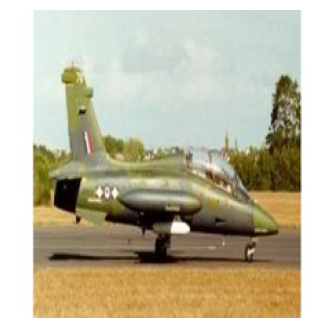

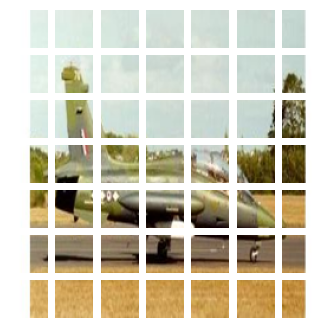

In [23]:
patch_size = 32  # Size of the patches to be extracted from the input images

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0].astype("uint8"))
plt.axis("off")

patches = Patches(patch_size)(np.expand_dims(x_train[0], axis=0))
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"{patches.shape[1]} patches per image \n{patches.shape[-1]} elements per patch")


n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

## Implement the patch encoding layer

The `PatchEncoder` layer linearly transforms a patch by projecting it into a
vector of size `projection_dim`. It also adds a learnable position
embedding to the projected vector.

In [24]:

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    # Override function to avoid error while saving model
    def get_config(self):
        config = super().get_config().copy()
        config.update(
            {
                "input_shape": input_shape,
                "patch_size": patch_size,
                "num_patches": num_patches,
                "projection_dim": projection_dim,
                "num_heads": num_heads,
                "transformer_units": transformer_units,
                "transformer_layers": transformer_layers,
                "mlp_head_units": mlp_head_units,
            }
        )
        return config

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded


## Build the ViT model

The ViT model has multiple Transformer blocks.
The `MultiHeadAttention` layer is used for self-attention,
applied to the sequence of image patches. The encoded patches (skip connection)
and self-attention layer outputs are normalized and fed into a
multilayer perceptron (MLP).
The model outputs four dimensions representing
the bounding box coordinates of an object.

In [25]:

def create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    inputs = keras.Input(shape=input_shape)
    # Create patches
    patches = Patches(patch_size)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    bounding_box = layers.Dense(4)(
        features
    )  # Final four neurons that output bounding box

    # return Keras model.
    return keras.Model(inputs=inputs, outputs=bounding_box)


## Run the experiment

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 1.0218 - val_loss: 0.3546
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.3448 - val_loss: 0.2346
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.2657 - val_loss: 0.1559
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1788 - val_loss: 0.0724
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 0.1301 - val_loss: 0.0430
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0987 - val_loss: 0.0253
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0812 - val_loss: 0.0051
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0573 - val_loss: 0.0043
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0465 - val_loss: 0.0018
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - loss: 0.0368 - val_loss: 0.0016
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0305 - val_loss: 0.0015
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/st

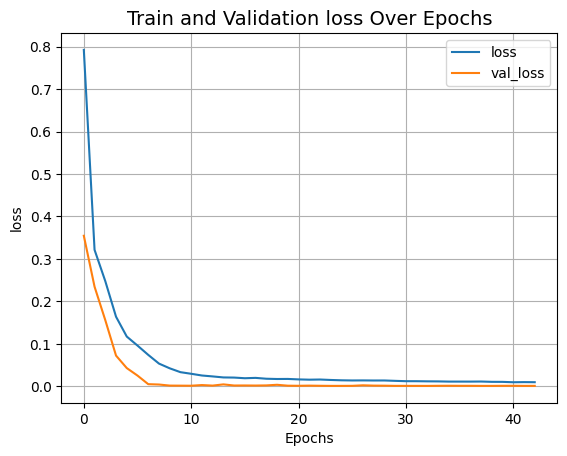

In [26]:

def run_experiment(model, learning_rate, weight_decay, batch_size, num_epochs):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    # Compile model.
    model.compile(optimizer=optimizer, loss=keras.losses.MeanSquaredError())

    checkpoint_filepath = "vit_object_detector.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[
            checkpoint_callback,
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=10),
        ],
    )

    return history


input_shape = (image_size, image_size, 3)  # input image shape
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 32
num_epochs = 100
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
# Size of the transformer layers
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 4
mlp_head_units = [2048, 1024, 512, 64, 32]  # Size of the dense layers


history = []
num_patches = (image_size // patch_size) ** 2

vit_object_detector = create_vit_object_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
)

# Train model
history = run_experiment(
    vit_object_detector, learning_rate, weight_decay, batch_size, num_epochs
)


def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_history("loss")


## Evaluate the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
mean_iou: 0.8872780938918167


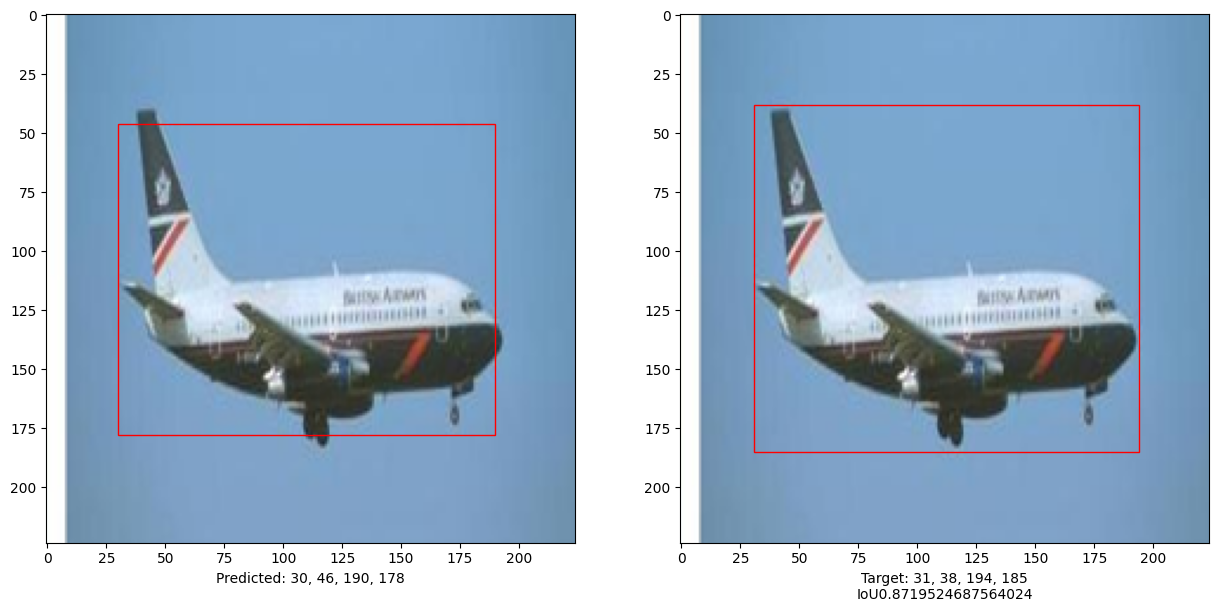

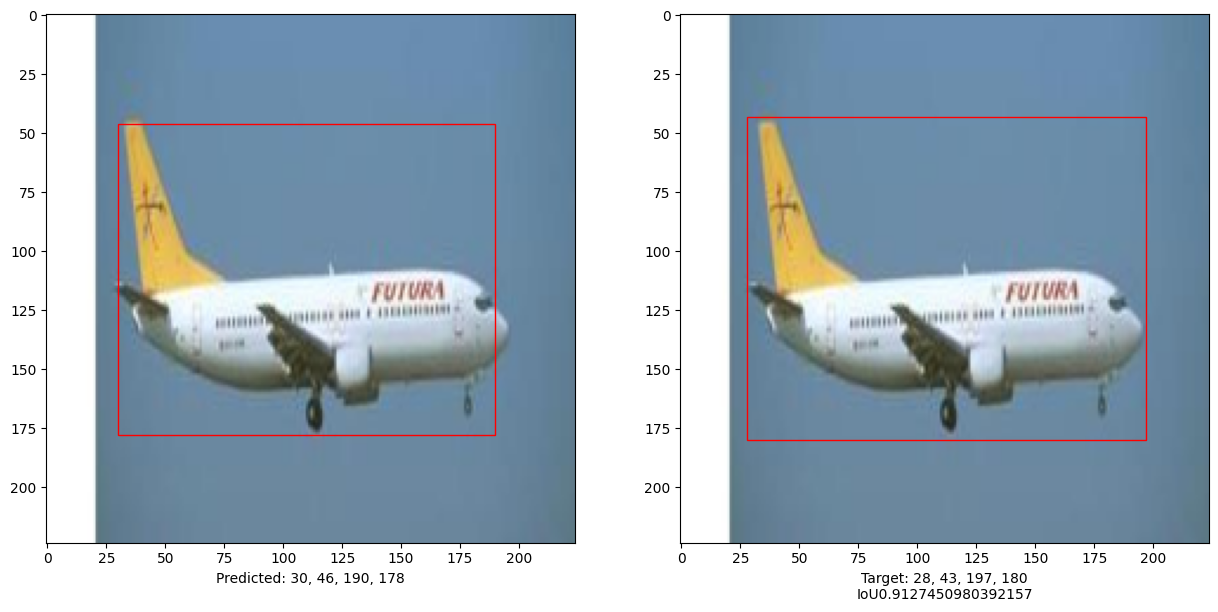

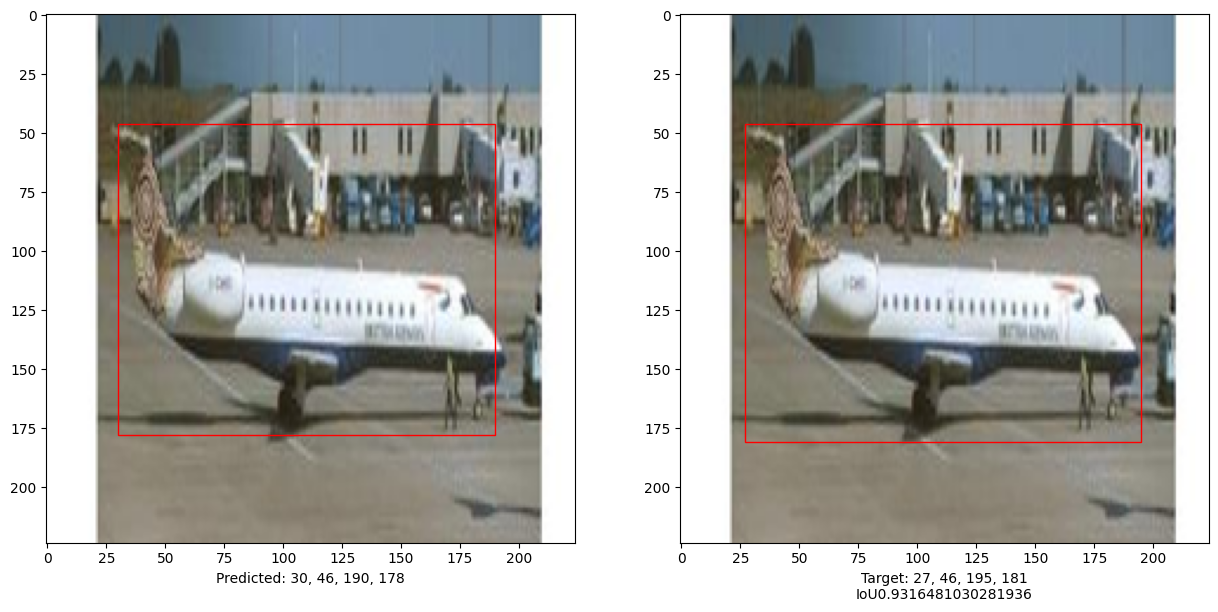

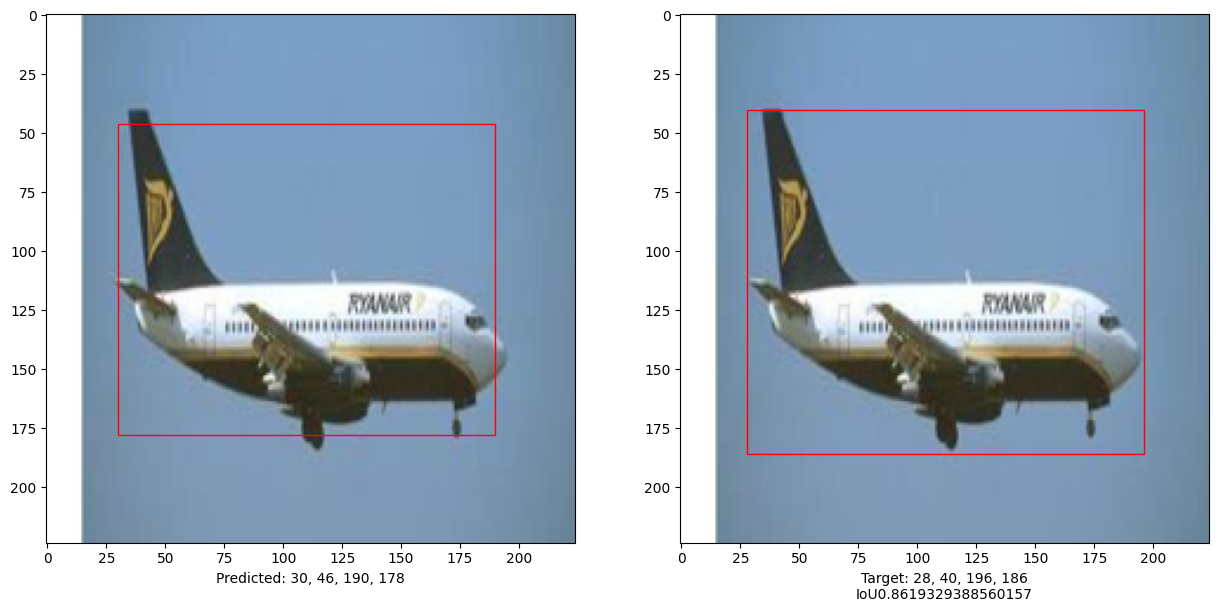

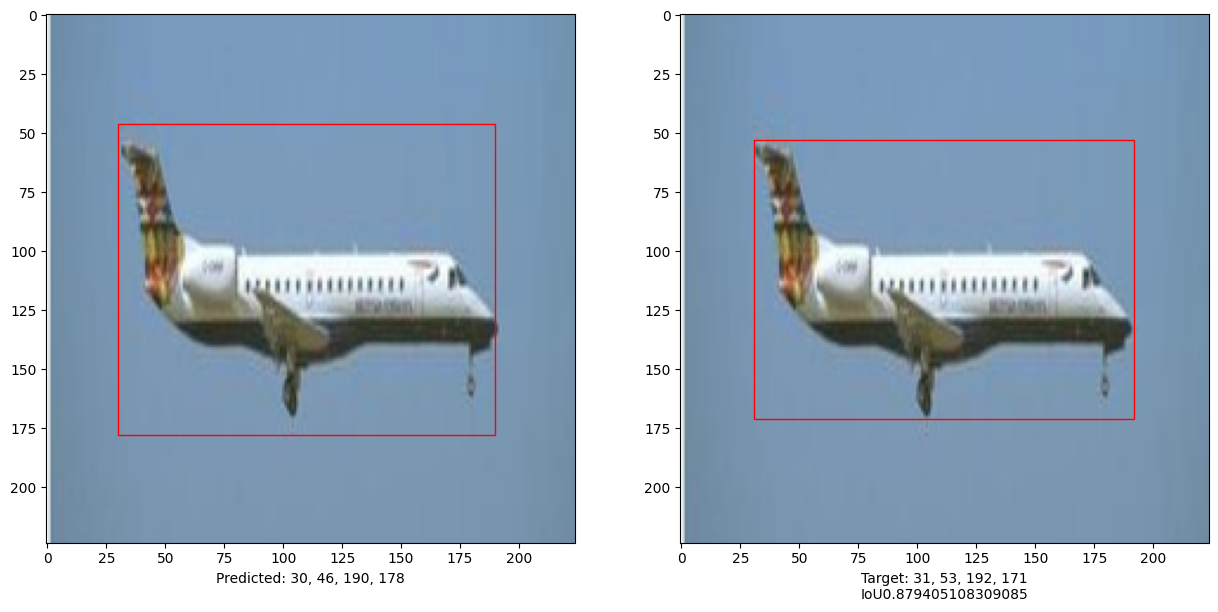

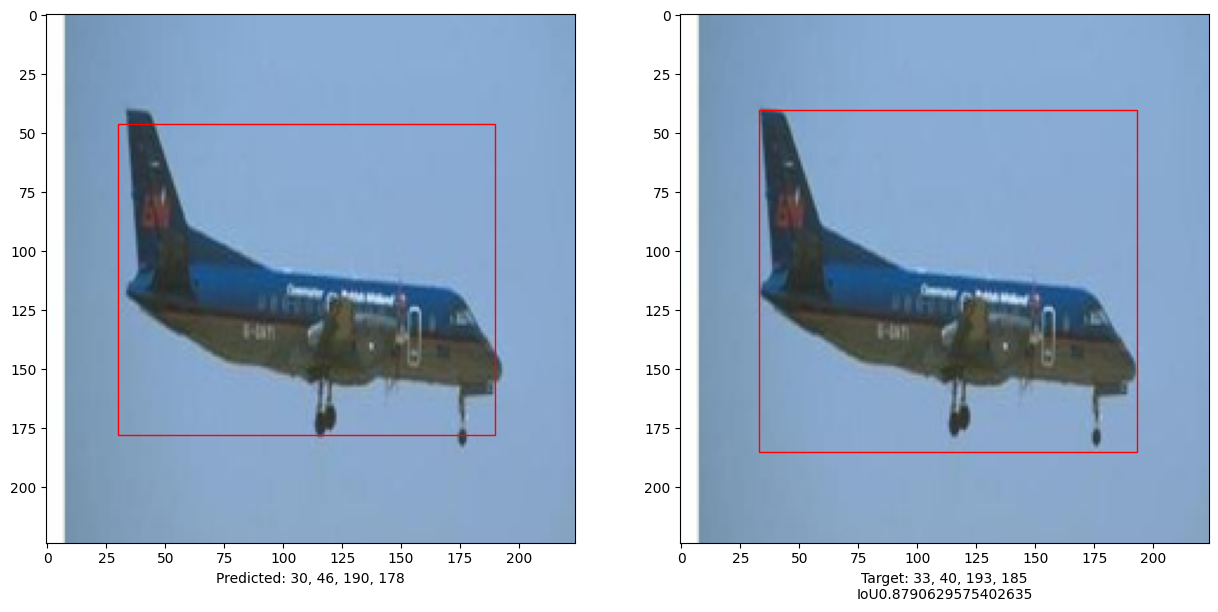

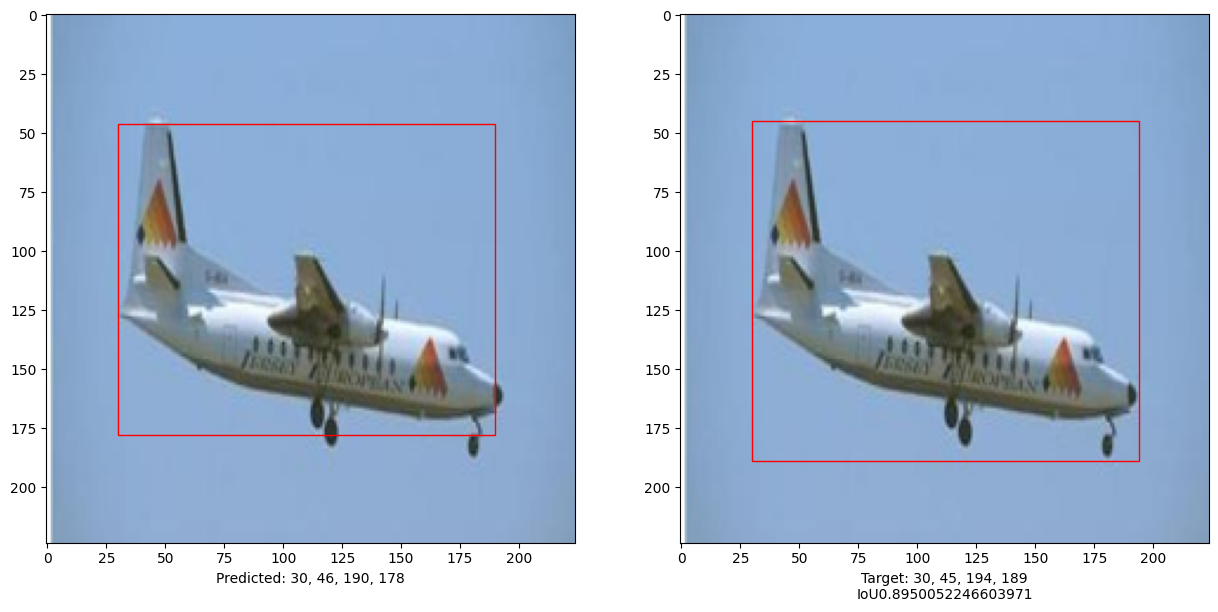

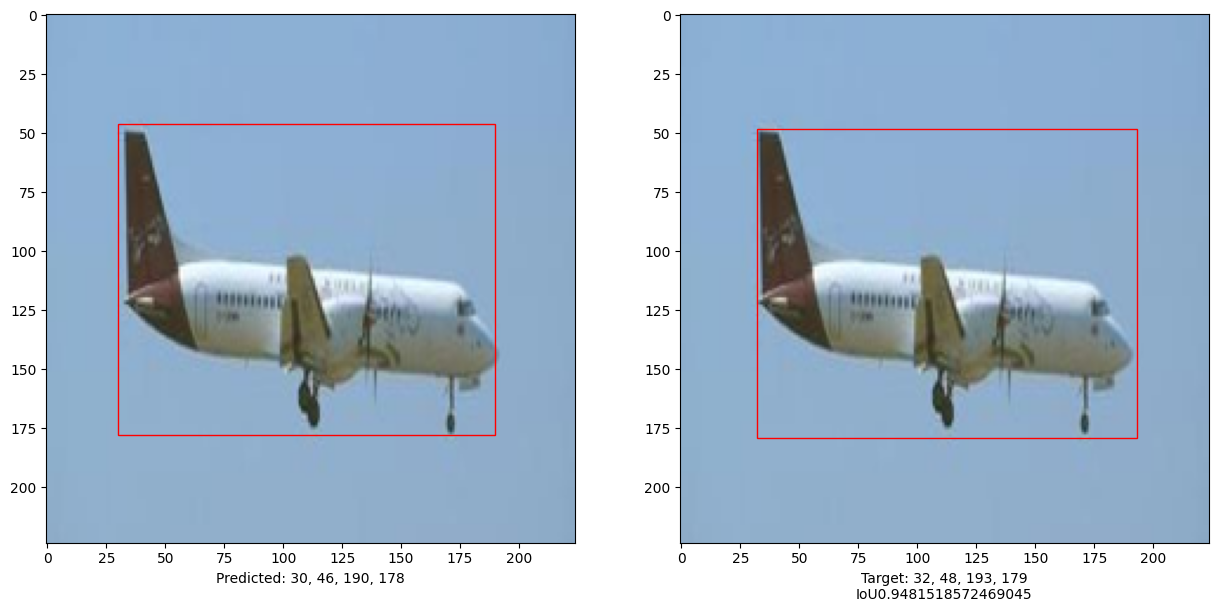

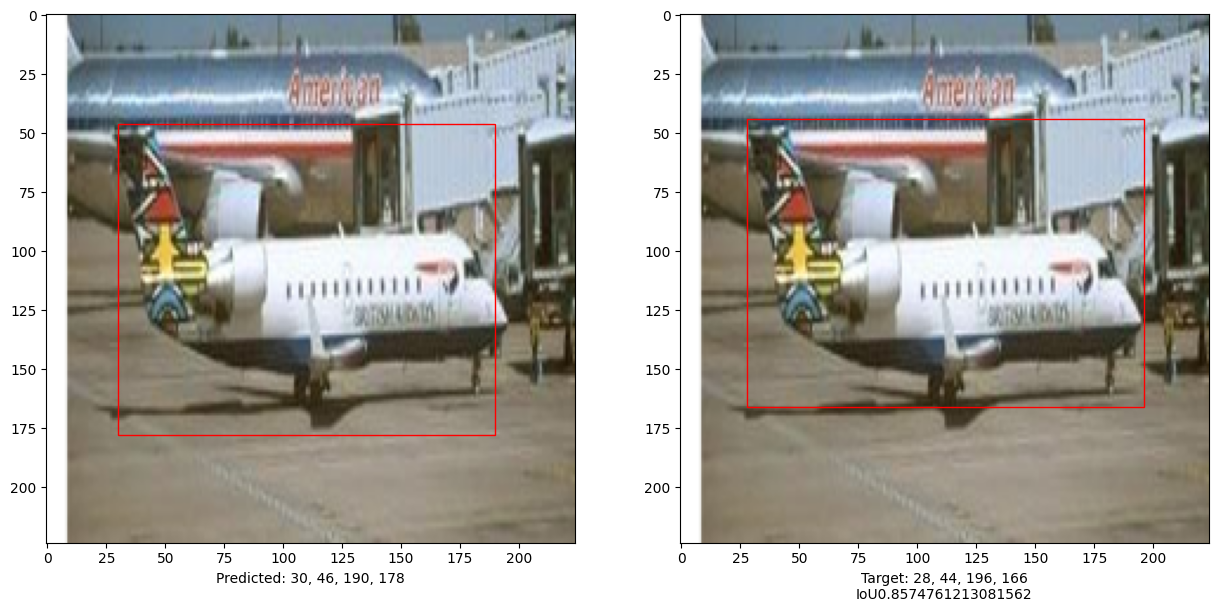

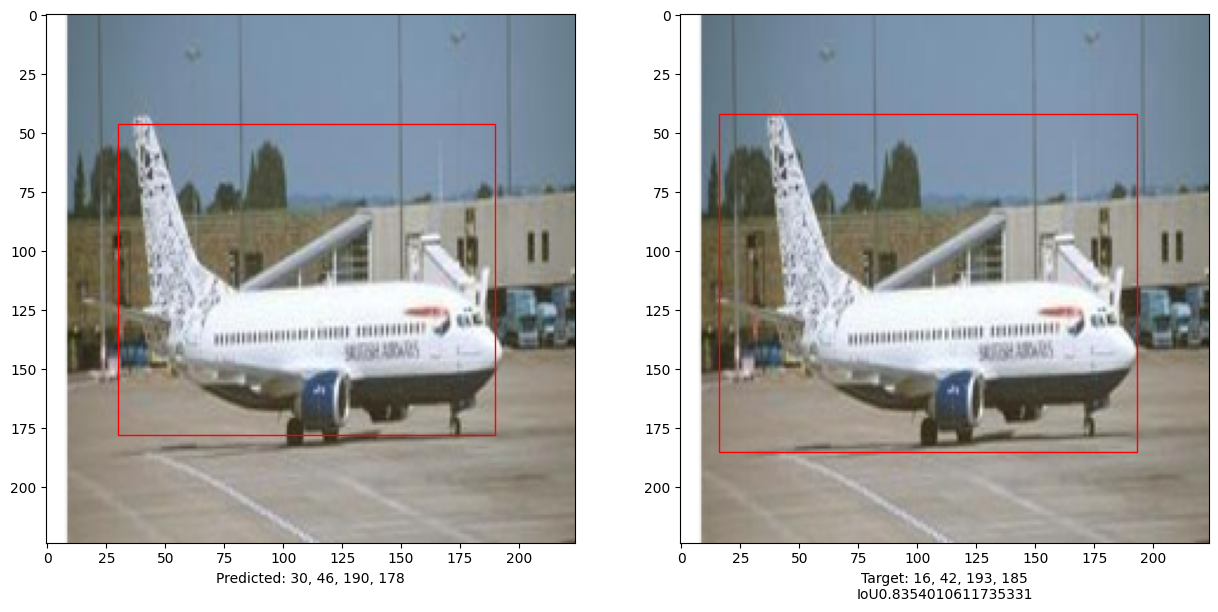

In [27]:
import matplotlib.patches as patches

# Saves the model in current path
vit_object_detector.save("vit_object_detector.keras")


# To calculate IoU (intersection over union, given two bounding boxes)
def bounding_box_intersection_over_union(box_predicted, box_truth):
    # get (x, y) coordinates of intersection of bounding boxes
    top_x_intersect = max(box_predicted[0], box_truth[0])
    top_y_intersect = max(box_predicted[1], box_truth[1])
    bottom_x_intersect = min(box_predicted[2], box_truth[2])
    bottom_y_intersect = min(box_predicted[3], box_truth[3])

    # calculate area of the intersection bb (bounding box)
    intersection_area = max(0, bottom_x_intersect - top_x_intersect + 1) * max(
        0, bottom_y_intersect - top_y_intersect + 1
    )

    # calculate area of the prediction bb and ground-truth bb
    box_predicted_area = (box_predicted[2] - box_predicted[0] + 1) * (
        box_predicted[3] - box_predicted[1] + 1
    )
    box_truth_area = (box_truth[2] - box_truth[0] + 1) * (
        box_truth[3] - box_truth[1] + 1
    )

    # calculate intersection over union by taking intersection
    # area and dividing it by the sum of predicted bb and ground truth
    # bb areas subtracted by  the interesection area

    # return ioU
    return intersection_area / float(
        box_predicted_area + box_truth_area - intersection_area
    )


i, mean_iou = 0, 0

# Compare results for 10 images in the test set
for input_image in x_test[:10]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
    im = input_image

    # Display the image
    ax1.imshow(im.astype("uint8"))
    ax2.imshow(im.astype("uint8"))

    input_image = cv2.resize(
        input_image, (image_size, image_size), interpolation=cv2.INTER_AREA
    )
    input_image = np.expand_dims(input_image, axis=0)
    preds = vit_object_detector.predict(input_image)[0]

    (h, w) = (im).shape[0:2]

    top_left_x, top_left_y = int(preds[0] * w), int(preds[1] * h)

    bottom_right_x, bottom_right_y = int(preds[2] * w), int(preds[3] * h)

    box_predicted = [top_left_x, top_left_y, bottom_right_x, bottom_right_y]
    # Create the bounding box
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax1.add_patch(rect)
    ax1.set_xlabel(
        "Predicted: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
    )

    top_left_x, top_left_y = int(y_test[i][0] * w), int(y_test[i][1] * h)

    bottom_right_x, bottom_right_y = int(y_test[i][2] * w), int(y_test[i][3] * h)

    box_truth = top_left_x, top_left_y, bottom_right_x, bottom_right_y

    mean_iou += bounding_box_intersection_over_union(box_predicted, box_truth)
    # Create the bounding box
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        bottom_right_x - top_left_x,
        bottom_right_y - top_left_y,
        facecolor="none",
        edgecolor="red",
        linewidth=1,
    )
    # Add the bounding box to the image
    ax2.add_patch(rect)
    ax2.set_xlabel(
        "Target: "
        + str(top_left_x)
        + ", "
        + str(top_left_y)
        + ", "
        + str(bottom_right_x)
        + ", "
        + str(bottom_right_y)
        + "\n"
        + "IoU"
        + str(bounding_box_intersection_over_union(box_predicted, box_truth))
    )
    i = i + 1

print("mean_iou: " + str(mean_iou / len(x_test[:10])))
plt.show()

This example demonstrates that a pure Transformer can be trained
to predict the bounding boxes of an object in a given image,
thus extending the use of Transformers to object detection tasks.
The model can be improved further by tuning hyper-parameters and pre-training.